In [1]:
"""
==========================================================
Image scanning microscopy on a simulated tubulin network
==========================================================

A 5x5 SPAD array looks at a synthetic microtubule phantom. Each detector
element sees the object through its own displaced PSF, and the reconstructions
below undo that displacement in different ways:

1. the ground-truth phantom,
2. the open-pinhole confocal image (the plain sum over the 25 elements),
3. adaptive pixel reassignment (APR-ISM),
4. the eSRRF radial-gradient-convergence map of the confocal image,
5. focus-ISM, which splits the reassigned photons into in-focus signal
   and out-of-focus background,
6. eSRRF applied on top of the APR-ISM image.
"""

import sys
from pathlib import Path
import os
# `__file__` does not exist inside a notebook; fall back to the working directory
_HERE_FILE = Path(globals().get("__file__", os.path.join(os.getcwd(), "example.py")))

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import fftconvolve

import tttrlib

# The phantom and the array-detector PSF model are simulation helpers, not part
# of the library.
sim_dir = _HERE_FILE.resolve().parent.parent / "simulation"
if str(sim_dir) not in sys.path:
    sys.path.insert(0, str(sim_dir))

from generate_tubulin_phantom import generate_tubulin_phantom
from simulate import generate_ism_psf

In [2]:
# Ground truth: a synthetic microtubule network at 25 nm per pixel.
pixel_size_nm = 25.0
ground_truth = generate_tubulin_phantom(
    n_filaments=12, size_px=128, pixel_size_nm=pixel_size_nm
)

In [3]:
# The detector: a 5x5 SPAD array at 0.5 Airy units pitch. Element *k* sees the
# product of the excitation PSF and its own displaced detection PSF, so its
# image of a point object is centred half-way to the element's own offset --
# the displacement ISM exists to undo.
psf_sim = generate_ism_psf(
    na=1.4,
    wavelength_exc=488.0,
    wavelength_det=520.0,
    n_det=5,
    pitch_au=0.5,
    nx=64,
    ny=64,
    pixel_size_nm=pixel_size_nm,
)
channel_psfs = psf_sim["channel_psfs"]

n_det = channel_psfs.shape[0]
ny, nx = ground_truth.shape
detector_cube = np.zeros((n_det, ny, nx), dtype=np.float64)
for k in range(n_det):
    detector_cube[k] = fftconvolve(ground_truth, channel_psfs[k], mode="same")

rng = np.random.default_rng(1)
detector_cube = rng.poisson(np.clip(detector_cube * 150.0, 0, None)).astype(np.float64)

In [4]:
# Reconstructions. The plain channel sum is what an open-pinhole confocal would
# record; everything else exploits the per-element displacement.
clsm_sum = detector_cube.sum(axis=0)

apr_ism = tttrlib.CLSMSuperRes.apr_reconstruction(detector_cube, usf=10)[0]

# APR only moves photons between pixels. The totals differ by a fraction of a
# percent because the Fourier shift rings slightly on shot noise and the
# reference clips the negative lobes away, as BrightEyes-ISM does.
print(f"confocal sum: {clsm_sum.sum():.0f} photons")
print(f"APR-ISM     : {apr_ism.sum():.0f} photons "
      f"({100 * (apr_ism.sum() / clsm_sum.sum() - 1):+.2f} %)")

focus_signal, focus_background, _ = tttrlib.CLSMSuperRes.focus_reconstruction(
    detector_cube, sigma_bound=2.0, calibration_size=16, parallelize=True
)

# eSRRF on the confocal image, and on the reassigned one. A light smoothing
# first keeps the gradient estimate from chasing shot noise.
rgc_confocal = tttrlib.CLSMSuperRes.rgc_map(
    gaussian_filter(clsm_sum, sigma=0.8),
    magnification=4, fwhm=2.5, sensitivity=1, intensity_weighting=True,
)
rgc_on_ism = tttrlib.CLSMSuperRes.rgc_map(
    gaussian_filter(apr_ism, sigma=0.8),
    magnification=4, fwhm=2.5, sensitivity=1, intensity_weighting=True,
)

confocal sum: 2214935 photons
APR-ISM     : 2230570 photons (+0.71 %)


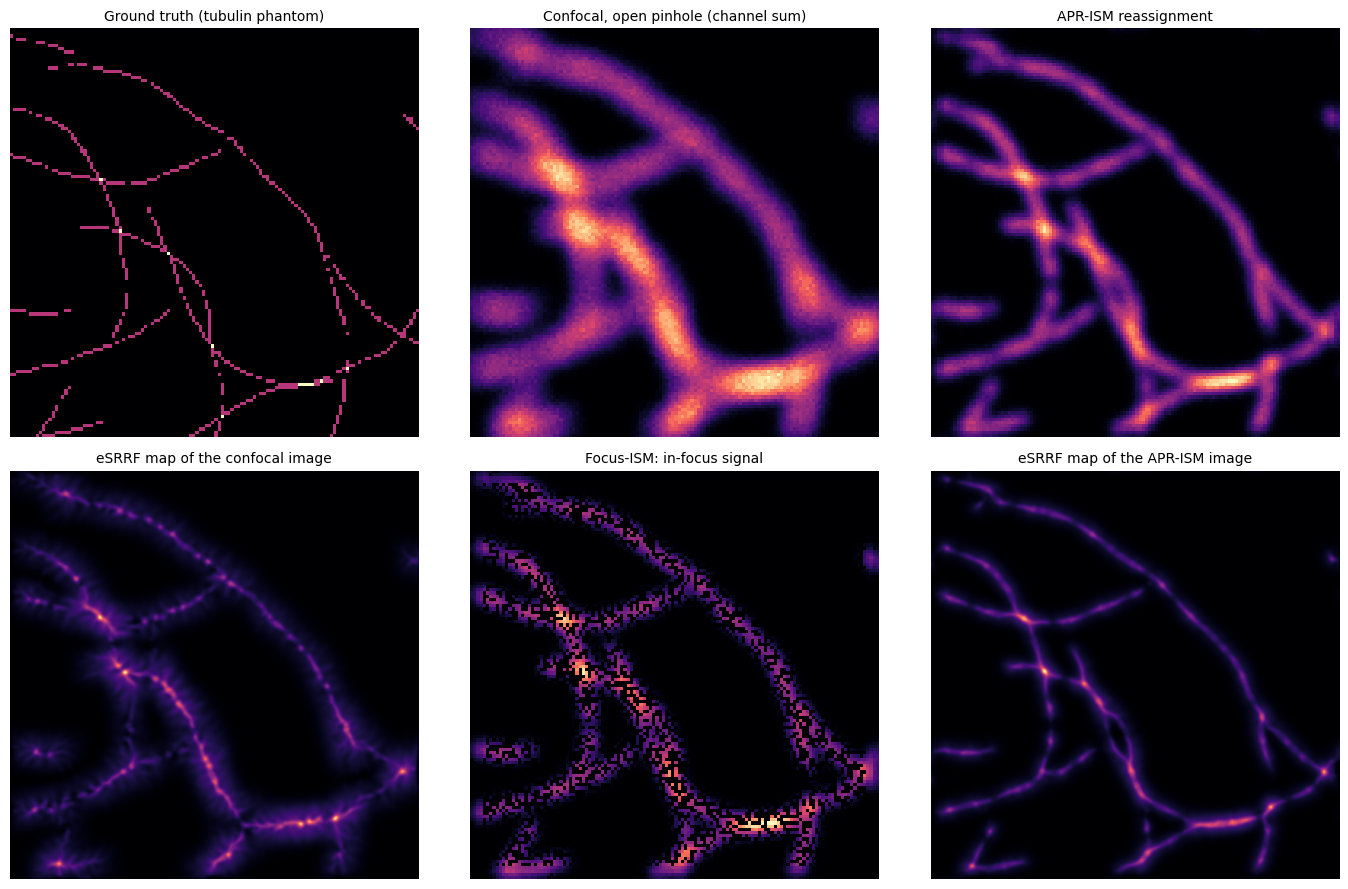

In [5]:
# Side by side.
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
panels = [
    ("Ground truth (tubulin phantom)", ground_truth),
    ("Confocal, open pinhole (channel sum)", clsm_sum),
    ("APR-ISM reassignment", apr_ism),
    ("eSRRF map of the confocal image", rgc_confocal),
    ("Focus-ISM: in-focus signal", focus_signal),
    ("eSRRF map of the APR-ISM image", rgc_on_ism),
]
for ax, (title, img) in zip(axes.ravel(), panels):
    ax.imshow(img, cmap="magma", origin="lower")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()